# 1. Offsetspannung am OP A 3
### Angabe 
Messen und gleichen Sie die Offsetspannung am OP A_3 ab. Überlegen Sie sich dazu eine geeignete Verstärkerschaltung.

### Plan

![Invertierender Verstaerker](notebook_images/invertierender%20verstaerker.png)

```
U_1 = 0V
U_A = A (U_E + U_OS)
U_A = (1+ R_2 / R_1) V_OS
```

Laut datenblatt offset ca 1mV. -> Verstaerkung mit 1000 ist gut.

```
R2 = 1M, R1 = 1k
A = 1+ 1kΩ/1MΩ​ = 1001
```

`U_A` messen


In [31]:
import pandas as pd
import numpy as np

Ue = 50e-3 # peak voltage

def calcBode(df):
    df['A'] = 20 * np.log10(df['Ua'] / Ue)
    df['phi'] = 360*df['f']*df['DeltaT']
    return df

df_I = calcBode(pd.read_csv("./data/BodeI.csv"))
df_NI = calcBode(pd.read_csv("./data/BodeNI.csv"))

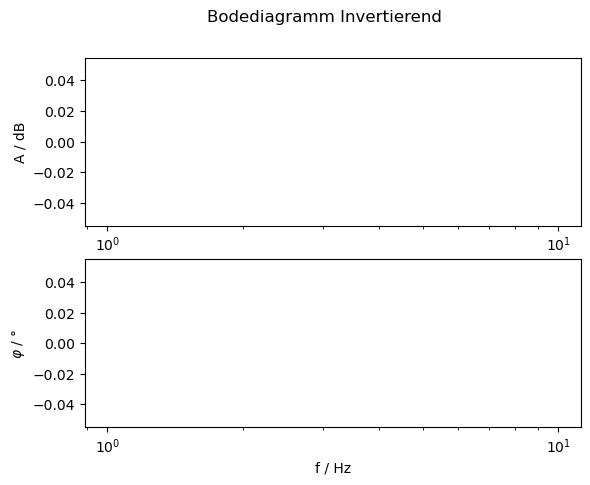

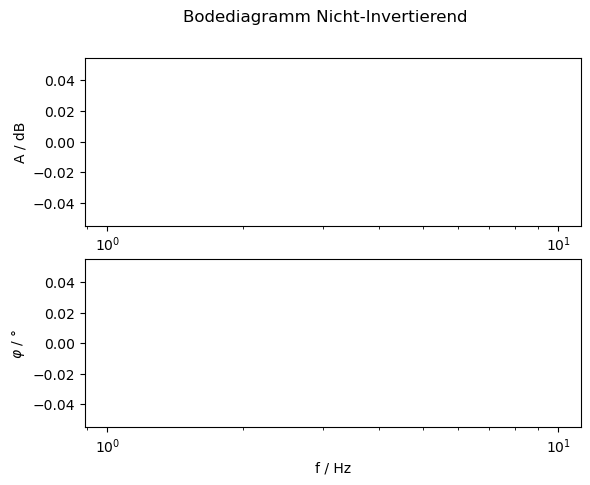

In [ ]:
import matplotlib.pyplot as plt

def plot_bode(df):
    fig, (ax_abs, ax_arg) = plt.subplots(nrows=2, ncols=1)
    ax_abs.set_ylabel("A / dB")
    ax_abs.set_xscale('log')
    ax_abs.plot(df['f'], df['A'])

    ax_arg.set_xscale('log')
    ax_arg.set_xlabel("f / Hz")
    ax_arg.set_ylabel("$\\varphi$ / °")
    ax_arg.plot(df['f'], df['phi'])

    return fig

fig_I = plot_bode(df_I)
fig_I.suptitle('Bodediagramm Invertierend')
fig_I.savefig("./latex/images/bode_I.png")
fig_NI = plot_bode(df_NI)
fig_NI.suptitle('Bodediagramm Nicht-Invertierend')
fig_NI.savefig("./latex/images/bode_NI.png")


In [57]:
data = df_I.merge(df_NI, on='f', suffixes=('_I', '_NI') )
data

,f,Ua_I,DeltaT_I,A_I,phi_I,Ua_NI,DeltaT_NI,A_NI,phi_NI
0,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,30000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,80000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
latex = data.to_latex(
    index=False,
    formatters={
        'f': "{:.0e}".format
    }
)
print(latex)

\begin{tabular}{rrrrrrrrr}
\toprule
f & Ua_I & DeltaT_I & A_I & phi_I & Ua_NI & DeltaT_NI & A_NI & phi_NI \\
\midrule
1e+01 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
1e+02 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
3e+02 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
1e+03 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
3e+03 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
1e+04 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
3e+04 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
8e+04 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
1e+05 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
3e+05 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
8e+05 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
1e+06 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
3e+06 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
\bottomrule
\end{tabular}

